## MNIST Image Classification with PyTorch

This notebook implements a complete pipeline for classifying handwritten digits from the MNIST dataset using PyTorch

## Imports

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [ ]:
def set_seed(
    seed: int = 42
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # using gpu operations that give same result each time
    torch.backends.cudnn.deterministic = True

    # stops pytorch from using different gpy algos
    torch.backends.cudnn.benchmark = False

set_seed(42)

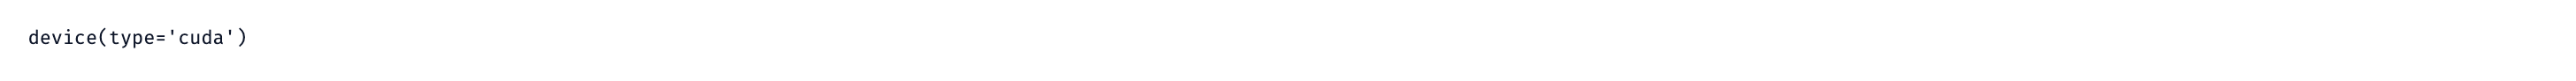

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
device

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean = (0.1307,),
        std = (0.3081,)
    )
])

## Dataset load

In [ ]:
train_ds = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

## Train and Validation data split

In [ ]:
train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    dataset = train_ds,
    lengths = [train_size, val_size]
)

## Dataloader

In [ ]:
batch_size = 64

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    shuffle = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = False
)

In [ ]:
print(f"Training samples : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples : {len(test_dataset)}")

Training samples : 50000
Validation samples : 10000
Test samples : 10000


## Model Architecture

Input batch

Shape: (4, 1, 28, 28)

        │
        ▼

Flatten

x.view(x.size(0), -1)

        │
        ▼

Shape: (4, 784)

        │
        ▼

Linear Layer

784 → 256

        │
        ▼

ReLU

Negative values become 0

        │
        ▼

Dropout(0.2)

Randomly disables 20% neurons during training

        │
        ▼

Linear Layer

256 → 128

        │
        ▼

ReLU

        │
        ▼

Dropout(0.2)

        │
        ▼

Output Linear Layer

128 → 10

        │
        ▼


Output shape: (4, 10)

10 raw scores for digits 0–9

In [ ]:
class MLP(nn.Module):

    def __init__(
        self,
        activation: str = "relu",
        dropout: float = 0.2,
        input_size: int = 784,
        hidden_sizes : list[int] = [256, 128],
        num_classes : int = 10

    ):
        super().__init__()

        activations = {
            "relu" : nn.ReLU(),
            "leaky_relu" : nn.LeakyReLU(negative_slope = 0.01),
            "gelu" : nn.GELU(),
            "tanh" : nn.Tanh(),
            "sigmoid" : nn.Sigmoid()
        }

        self.activation_func = activations[activation]

        self.dropout = nn.Dropout(p = dropout)

        layers = []

        prev_size = input_size

        for hidden_size in hidden_sizes:

            layers.append(nn.Linear(prev_size, hidden_size))

            layers.append(self.activation_func)

            layers.append(self.dropout)

            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

    def get_num_parameters(self):

        return sum(
            p.numel()
            for p in self.parameters() if
            p.requires_grad
        )

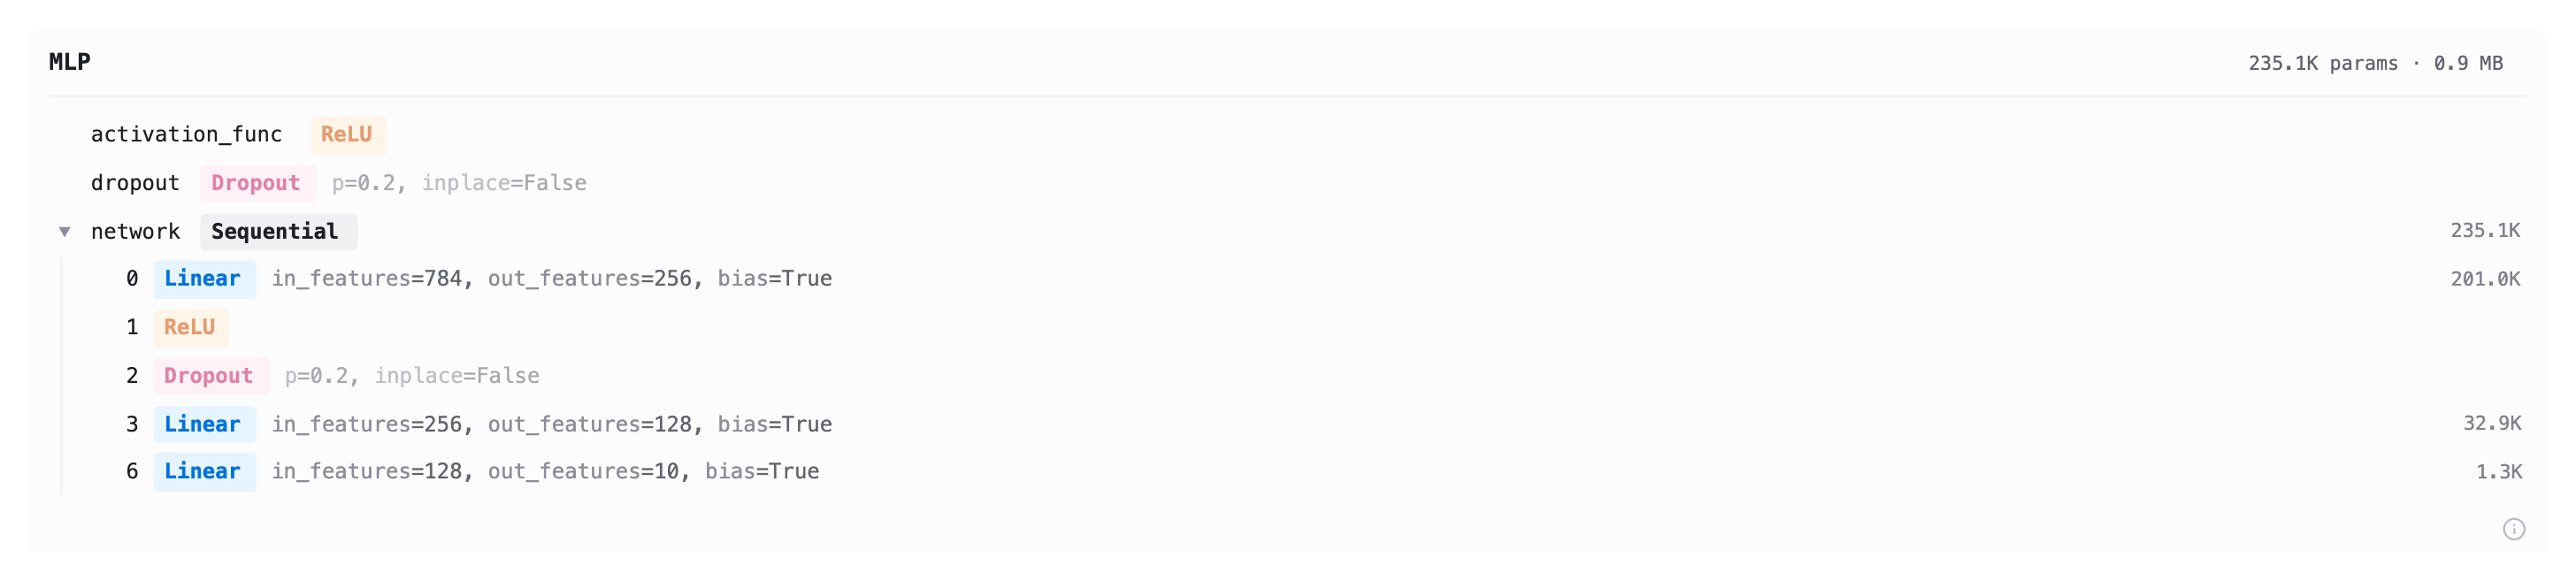

In [ ]:
test_model = MLP()
test_model

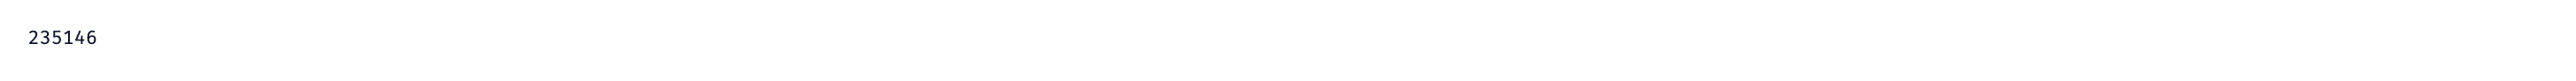

In [ ]:
test_model.get_num_parameters()

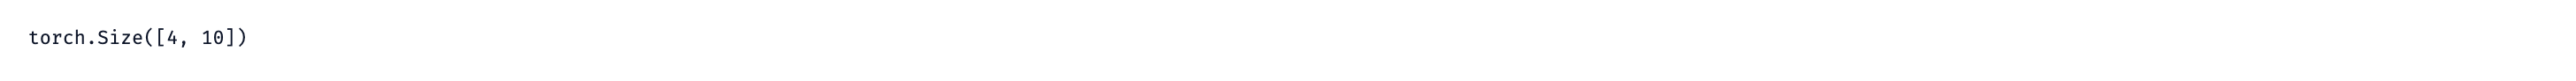

In [ ]:
x = torch.randn(4, 1, 28, 28)
output = test_model(x)
output.shape

## Training setup

In [ ]:
def create_model_and_optimizer(
    hidden_sizes: list[int] = [256, 128],
    activation: str = "relu",
    dropout: float = 0.2,
    lr: float = 0.001,
    weight_decay: float = 0.0001
):
    model = MLP(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr = lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    return (model, criterion, optimizer, scheduler)

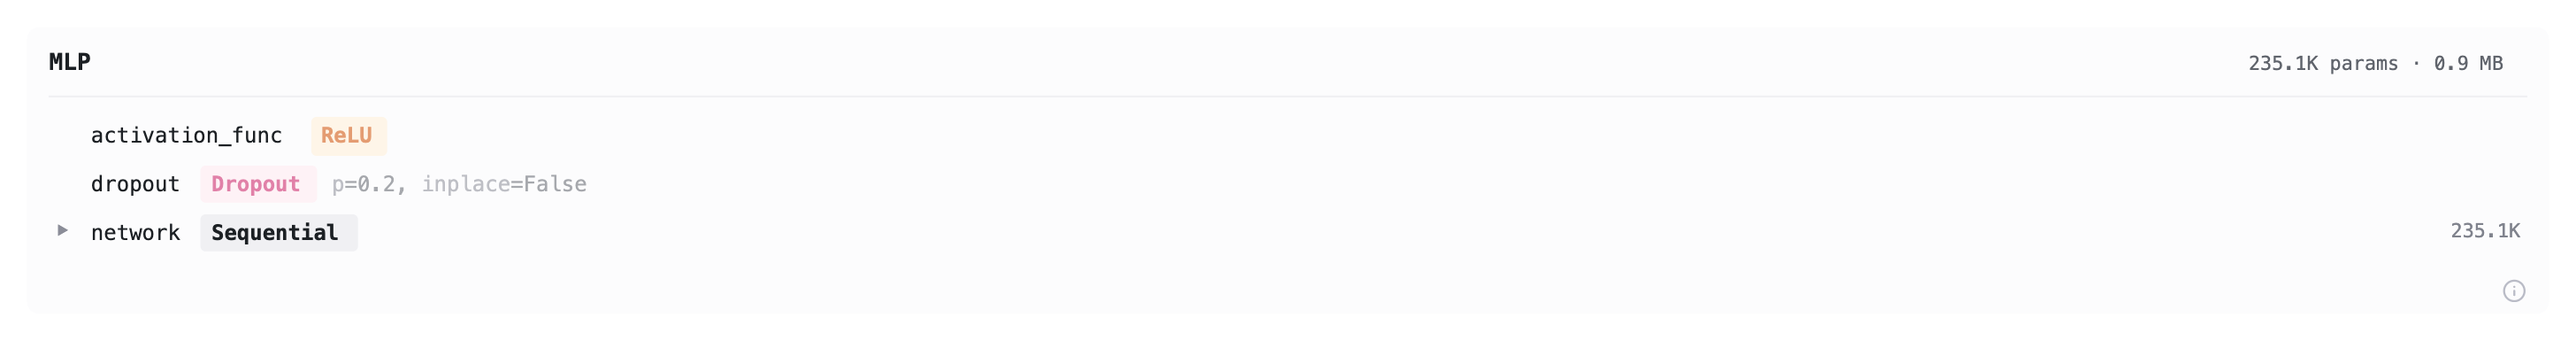

In [ ]:
model1, criterion, optimizer, scheduler = create_model_and_optimizer()
model1.to(device)
model1

## Training and evaluation functions

In [ ]:
def train_one_epoch(
    loader,
    criterion,
    optimizer,
    device,
    model : MLP
):

    model.train()

    net_loss = 0.0

    total = 0

    correct = 0

    for images, labels in loader:

        images = images.to(device)    # batchSize, 1, 28, 28

        labels = labels.to(device)    # batchSize

        outputs = model(images)       # batchSize, 10

        loss = criterion(outputs, labels)   

        optimizer.zero_grad()  

        loss.backward()

        optimizer.step()

        net_loss = net_loss + loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total = total + labels.size(0)

        correct = correct + predicted.eq(labels).sum().item()

    epoch_loss = net_loss / total

    epoch_accuracy = 100.0 * correct / total

    return (epoch_loss, epoch_accuracy)

In [ ]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    Loss = 0.0

    correct = 0

    total = 0

    all_predictions = []

    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            Loss = Loss + loss.item() * images.size(0)

            _, predicted = outputs.max(1)

            total = total + labels.size(0)

            correct = correct + predicted.eq(labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    epoch_loss = Loss / total

    epoch_accuracy = 100.0 * correct / total

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_predictions),
        np.array(all_labels)
    )

## Training Loop

In [ ]:
def train_model(
    model,
    device,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs: int = 20,
    patience = 7
):

    history = {
        "train_loss" : [],
        "train_accuracy" : [],
        "val_loss" : [],
        "val_accuracy" : [],
        "lr" : []
    }

    print(f"{'Epoch':>5}   |   {'Train Loss':>10}   |   {'Train Acc':>9}   |   {'Val Loss':>9}   |   {'Val Acc':>8}   |   {'LR':>8}")

    best_val_loss = float('inf')

    best_model_state = None

    epochs_no_improve = 0

    for epoch in range(1, num_epochs + 1):

        train_loss, train_accuracy = train_one_epoch(
            loader = train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            model=model
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['lr'].append(current_lr)

        print(f'{epoch:>5}   |   {train_loss:>10.4f}   |   {train_accuracy:>9.2f}   |   {val_loss:>9.4f}   |   {val_accuracy:>8.2f}   |   {current_lr:>8.2e}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0

        else:
            epochs_no_improve = epochs_no_improve + 1

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch} epochs')
            break

    if best_model_state is not None:  
        model.load_state_dict(best_model_state)

    return history

In [ ]:
history = train_model(
    model=model1,
    device=device,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=20,
    patience=7
)

Epoch   |   Train Loss   |   Train Acc   |    Val Loss   |    Val Acc   |         LR
    1   |       0.2926   |       91.22   |      0.1465   |      95.63   |   1.00e-03
    2   |       0.1395   |       95.78   |      0.1110   |      96.53   |   1.00e-03
    3   |       0.1078   |       96.65   |      0.0961   |      97.16   |   1.00e-03
    4   |       0.0897   |       97.19   |      0.0869   |      97.40   |   1.00e-03
    5   |       0.0784   |       97.52   |      0.0939   |      97.22   |   1.00e-03
    6   |       0.0693   |       97.77   |      0.0913   |      97.40   |   1.00e-03
    7   |       0.0651   |       97.85   |      0.0873   |      97.60   |   1.00e-03
    8   |       0.0614   |       97.97   |      0.0937   |      97.30   |   5.00e-04
    9   |       0.0390   |       98.71   |      0.0793   |      97.90   |   5.00e-04
   10   |       0.0326   |       98.93   |      0.0753   |      97.94   |   5.00e-04
   11   |       0.0302   |       99.06   |      0.0771   |      9

## Training curves

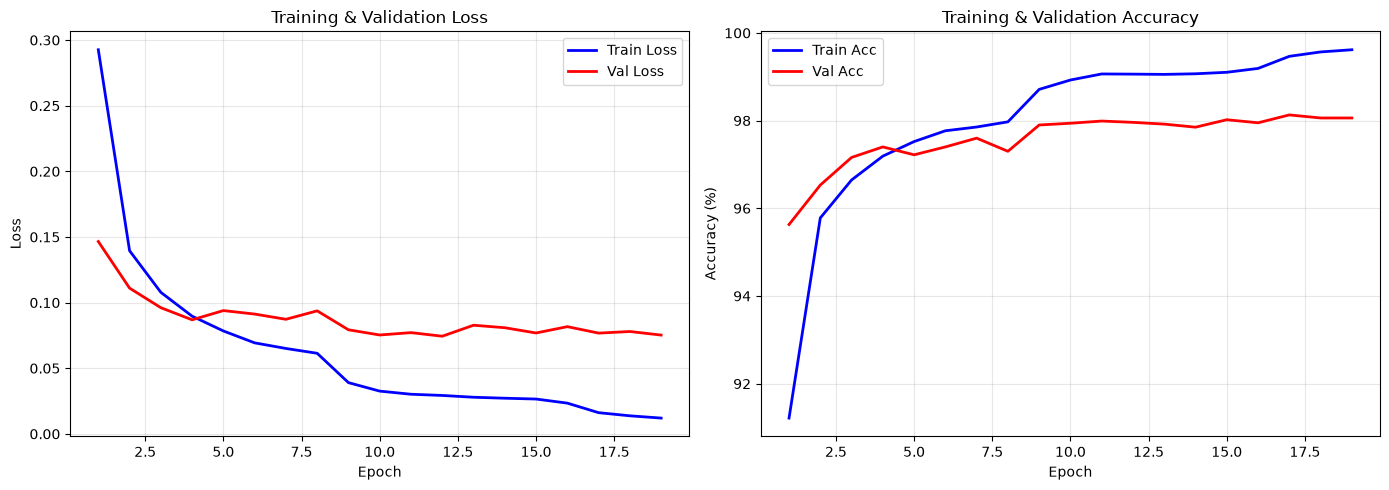

In [ ]:
def plot_training_curves(history):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_accuracy'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

In [ ]:
test_loss, test_accuracy, test_preds, test_labels = evaluate(
    model=model1,
    loader=train_loader,
    criterion=criterion,
    device=device
)

In [ ]:
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

Test loss: 0.0024895243001007475
Test accuracy: 99.962


## Architecture Experiments

In [ ]:
def run_experiment(
    hidden_sizes,
    activation='relu',
    dropout=0.2,
    lr=1e-3,
    epochs=15,
    name=None
):

    if name is None:
        name = f"{activation}_{'-'.join(map(str, hidden_sizes))}_drop{dropout}"

    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")

    model, criterion, optimizer, scheduler = create_model_and_optimizer(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout,
        lr=lr
    )
    model.to(device)

    history = train_model(
        model,
        device,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        epochs,
        patience=5
    )

    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

    return {
        'name': name,
        'model': model,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'params': model.get_num_parameters()
    }

experiments = [
    # Baseline
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.2, 'name': 'Baseline (256-128, ReLU)'},

    # Different architectures
    {'hidden_sizes': [512, 256], 'activation': 'relu', 'dropout': 0.2, 'name': 'Larger (512-256, ReLU)'},
    {'hidden_sizes': [128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Smaller (128-64, ReLU)'},
    {'hidden_sizes': [256, 128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Deeper (256-128-64, ReLU)'},

    # Different activations
    {'hidden_sizes': [256, 128], 'activation': 'leaky_relu', 'dropout': 0.2, 'name': 'LeakyReLU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'gelu', 'dropout': 0.2, 'name': 'GELU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'tanh', 'dropout': 0.2, 'name': 'Tanh (256-128)'},

    # Different dropout
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.0, 'name': 'No Dropout (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.5, 'name': 'High Dropout (256-128)'},
]

In [ ]:
results = []

for exp_config in experiments:
    result = run_experiment(
        hidden_sizes=exp_config['hidden_sizes'],
        activation=exp_config['activation'],
        dropout=exp_config['dropout'],
        name=exp_config['name'],
        epochs=20  
    )
    results.append(result)


Experiment: Baseline (256-128, ReLU)
Epoch   |   Train Loss   |   Train Acc   |    Val Loss   |    Val Acc   |         LR
    1   |       0.2964   |       91.00   |      0.1529   |      95.41   |   1.00e-03
    2   |       0.1350   |       95.90   |      0.1208   |      96.28   |   1.00e-03
    3   |       0.1060   |       96.78   |      0.0990   |      96.92   |   1.00e-03
    4   |       0.0913   |       97.15   |      0.0968   |      97.12   |   1.00e-03
    5   |       0.0775   |       97.52   |      0.0914   |      97.20   |   1.00e-03
    6   |       0.0695   |       97.77   |      0.0849   |      97.51   |   1.00e-03
    7   |       0.0658   |       97.98   |      0.0972   |      97.43   |   1.00e-03
    8   |       0.0628   |       97.97   |      0.0858   |      97.66   |   1.00e-03
    9   |       0.0559   |       98.13   |      0.0916   |      97.45   |   1.00e-03
   10   |       0.0567   |       98.18   |      0.0801   |      97.48   |   1.00e-03
   11   |       0.0524   | 

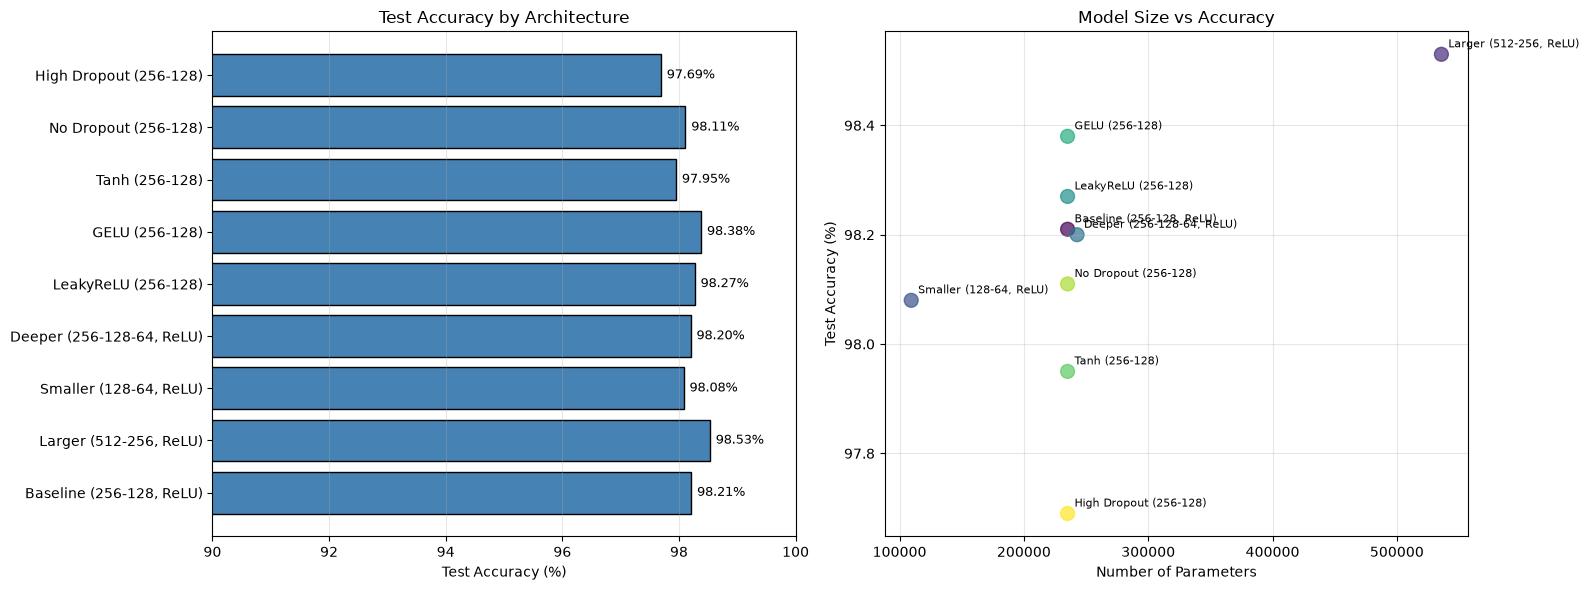

In [ ]:
def plot_experiment_comparison(results):

    names = [r['name'] for r in results]

    test_accs = [r['test_acc'] for r in results]

    params = [r['params'] for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))


    bars = axes[0].barh(range(len(names)), test_accs, color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names)
    axes[0].set_xlabel('Test Accuracy (%)')
    axes[0].set_title('Test Accuracy by Architecture')
    axes[0].set_xlim(90, 100)
    axes[0].grid(True, alpha=0.3, axis='x')


    for i, (bar, acc) in enumerate(zip(bars, test_accs)):
        axes[0].text(acc + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{acc:.2f}%', va='center', fontsize=9)


    scatter = axes[1].scatter(params, test_accs, c=range(len(results)), cmap='viridis', s=100, alpha=0.7)
    for i, name in enumerate(names):
        axes[1].annotate(name, (params[i], test_accs[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    axes[1].set_xlabel('Number of Parameters')
    axes[1].set_ylabel('Test Accuracy (%)')
    axes[1].set_title('Model Size vs Accuracy')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if results:
    plot_experiment_comparison(results)

In [ ]:
if results:

    print(f"{'Model':<35} {'Params':>10} {'Test Acc':>10} {'Test Loss':>10}")

    print("-" * 70)

    for r in sorted(results, key=lambda x: x['test_acc'], reverse=True):

        print(f"{r['name']:<35} {r['params']:>10,} {r['test_acc']:>10.2f}% {r['test_loss']:>10.4f}")

Model                                   Params   Test Acc  Test Loss
----------------------------------------------------------------------
Larger (512-256, ReLU)                 535,818      98.53%     0.0622
GELU (256-128)                         235,146      98.38%     0.0611
LeakyReLU (256-128)                    235,146      98.27%     0.0632
Baseline (256-128, ReLU)               235,146      98.21%     0.0713
Deeper (256-128-64, ReLU)              242,762      98.20%     0.0684
No Dropout (256-128)                   235,146      98.11%     0.0731
Smaller (128-64, ReLU)                 109,386      98.08%     0.0790
Tanh (256-128)                         235,146      97.95%     0.0658
High Dropout (256-128)                 235,146      97.69%     0.0827


## Saving best model

In [ ]:
if results:

    best_result = max(results, key=lambda x: x['test_acc'])

    best_model = best_result['model']

    save_path = 'best_mnist_mlp.pth'

    torch.save({
        'model_state_dict': best_model.state_dict(),
        'model_config': {
            'hidden_sizes': [512, 256],    
            'activation': 'relu',
            'dropout': 0.2
        },
        'test_accuracy': best_result['test_acc'],
        'num_parameters': best_result['params']
    }, save_path)

    print(f"Best model saved to {save_path}")

    print(f"Best model: {best_result['name']}")

    print(f"Test Accuracy: {best_result['test_acc']:.2f}%")

    print(f"Parameters: {best_result['params']:,}")

Best model saved to best_mnist_mlp.pth
Best model: Larger (512-256, ReLU)
Test Accuracy: 98.53%
Parameters: 535,818


In [ ]:
def load_model(checkpoint_path, device):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    config = checkpoint['model_config']

    model = MLP(hidden_sizes=config['hidden_sizes'], activation=config['activation'], dropout=config['dropout']).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()

    return (model, checkpoint)

In [ ]:
if os.path.exists('best_mnist_mlp.pth'):

    loaded_model, checkpoint = load_model('best_mnist_mlp.pth', device)

    test_loss_1, test_acc_1, _, _ = evaluate(loaded_model, test_loader, criterion, device)

    print(f'Loaded model test accuracy: {test_acc_1:.2f}%')

    print(f"Checkpoint test accuracy: {checkpoint['test_accuracy']:.2f}%") 

Loaded model test accuracy: 98.53%
Checkpoint test accuracy: 98.53%
